# Text Mining

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/quora-insincere-questions-classification/train.csv
/kaggle/input/quora-insincere-questions-classification/sample_submission.csv
/kaggle/input/quora-insincere-questions-classification/test.csv
/kaggle/input/quora-insincere-questions-classification/embeddings/paragram_300_sl999/paragram_300_sl999.txt
/kaggle/input/quora-insincere-questions-classification/embeddings/paragram_300_sl999/README.txt
/kaggle/input/quora-insincere-questions-classification/embeddings/wiki-news-300d-1M/wiki-news-300d-1M.vec
/kaggle/input/quora-insincere-questions-classification/embeddings/GoogleNews-vectors-negative300/GoogleNews-vectors-negative300.bin
/kaggle/input/quora-insincere-questions-classification/embeddings/glove.840B.300d/glove.840B.300d.txt


In [2]:
path='/kaggle/input/quora-insincere-questions-classification/train.csv'
train = pd.read_csv(path,nrows=1000)
train.head()

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0


In [3]:
#target=0 - can be asked in public forum
#target=1 - insincere questions
#qid is just ID - we can ignore

## Methods to convert text to numerical values
- Document Term Matrix/Term Document Metrix
- Using word2vec/Doc2vec

## Text cleaning for classification/regression/clustering
- Convert every character to lower case
- Using regular expression retail only alphabets (sometimes numbers, symbols(#&@ etc))
- Remove commonly used words
- Identify root form of the word (stemming, lemmatization)

In [4]:
## converting every character to lower case
docs=train['question_text'].str.lower()
docs.sample(20)


854                 what is the most real thing or idea?
852    which area in banglore is safest for working w...
419             what is the past form of must have been?
410    where is a good place for filming time lapse v...
277    i'm considering to buy a bike, a 1000cc japane...
736      what are some examples of fables and folktales?
954                     what are cons of surface mining?
452    what kind of therapy can help you forget a mem...
889      does the diameter of a bob affect the pendulum?
469    how can i find out the carrier by only using t...
740    what is the colour of methyl orange in limewater?
614    where can i find a free carpet installation in...
252    is there a time you felt like killing yourself...
106    what ways will a narcissist mother punish her ...
639             what are some cultural taboos in russia?
254    which college majors will increase my chances ...
923                         which football should i buy?
633    is it dangerous to have 

In [5]:
##remove non-alphabets
docs= docs.str.replace('[^a-z ]','') # retaining alphabets, spaces and remove evrything else

In [6]:
## remove commonly used words

import nltk #natural language tool kit
stopwords=nltk.corpus.stopwords.words('english')
stemmer=nltk.stem.PorterStemmer()
def clean_sentance(doc):
    words=doc.split(' ')
    words_clean=[stemmer.stem(word) for word in words if word not in stopwords] #removing the common words
# and stemming all the words
    return ' '.join(words_clean) #because sklearn expects one string
    
docs=docs.apply(clean_sentance)

In [7]:
#docs.apply(lambda v: v.split(' ')).head() - another way

In [8]:
#Example

# stemmer=nltk.stem.PorterStemmer()
# stemmer.stem('organization')

In [9]:
# Document term matrix- is also called as sparsity matrix because maximum will be 0 in the matrix

In [10]:
#Term Frequency - Inverse Document Frequency (TF-IDF)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

dtm_vectorizer=CountVectorizer()

train_x,validate_x,train_y,validate_y=train_test_split(docs,train['target'],test_size=0.2,random_state=1)

dtm_vectorizer.fit(train_x) #it only identifies unique words - only fit

#do not use fit and transform together

#always first fit and then transform on training, testing etc
#or the columns order will change in the test data


dtm_train=dtm_vectorizer.transform(train_x) # we are tranforming here on train data
#it will compress the matrix, ignore 0's and only give number - compressed output and will give it as input to model
dtm_validate=dtm_vectorizer.transform(validate_x) # we are tranforming here on test data


In [12]:
dtm_train #2405 unique values in training matrix

#800x2405 - total number of elements
#out of whihc 4822 non 0 values we have
# most of the are 0's. Hence, sparse metrix

<800x2415 sparse matrix of type '<class 'numpy.int64'>'
	with 4835 stored elements in Compressed Sparse Row format>

In [13]:
df_dtm_train=pd.DataFrame(dtm_train.toarray(),columns=dtm_vectorizer.get_feature_names(),index=train_x.index)
df_dtm_train

,aa,aadhar,abil,abl,abolish,aborigin,abroad,absent,absolut,absorb,...,yolk,york,yorkiepom,youtub,youv,yx,zealand,zero,zindagi,zxr
382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
521,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
908,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


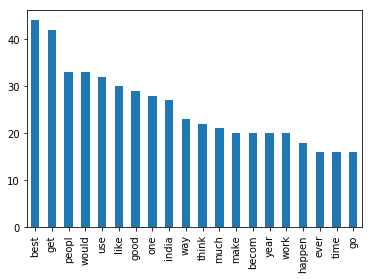

In [14]:
df_dtm_train.sum().sort_values(ascending=False).head(20).plot.bar()

In [15]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB().fit(dtm_train,train_y)
train_y_pred=model.predict(dtm_validate)

from sklearn.metrics import accuracy_score,f1_score
print(accuracy_score(validate_y,train_y_pred))
print(f1_score(validate_y,train_y_pred))

0.97
0.4


In [16]:
from nltk.sentiment import SentimentIntensityAnalyzer
sentiment_analyzer=SentimentIntensityAnalyzer()
sentiment_analyzer.polarity_scores('i like india')

/opt/conda/lib/python3.6/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


{'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.3612}